# HAM10000 - Clasificador de Lesiones Cutáneas con ResNet50
**Dataset:** HAM10000 (Human Against Machine with 10000 training images)  
**Modelo:** ResNet50 preentrenado con ImageNet + Fine-tuning  
**Framework:** TensorFlow / Keras

## Clases del Dataset
| Abreviatura | Descripción |
|---|---|
| `akiec` | Queratosis actínica / carcinoma intraepitelial |
| `bcc` | Carcinoma basocelular |
| `bkl` | Lesiones benignas tipo queratosis |
| `df` | Dermatofibroma |
| `mel` | Melanoma |
| `nv` | Nevos melanocíticos |
| `vasc` | Lesiones vasculares |


**Estructura esperada del dataset:**
```
HAM10000/
├── HAM10000_images_part_1/   ← imágenes .jpg
├── HAM10000_images_part_2/   ← imágenes .jpg
└── HAM10000_metadata.csv     ← metadatos con etiquetas
```

## 1. Instalación de Dependencias

In [1]:
#!pip install tensorflow pandas numpy matplotlib scikit-learn seaborn Pillow tqdm -q

## 2. Importaciones

In [2]:
import os
import random
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
from glob import glob

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, Model
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.utils import plot_model

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc
from sklearn.preprocessing import label_binarize
from sklearn.utils.class_weight import compute_class_weight

print(f'TensorFlow version: {tf.__version__}')
print(f'GPUs disponibles: {len(tf.config.list_physical_devices("GPU"))}')

SEED = 42
os.environ['PYTHONHASHSEED'] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

2026-06-04 16:17:38.431056: I tensorflow/core/util/port.cc:113] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-06-04 16:17:38.779870: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-06-04 16:17:38.780051: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-06-04 16:17:38.838209: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-06-04 16:17:38.959107: I tensorflow/core/platform/cpu_feature_guar

TensorFlow version: 2.15.0
GPUs disponibles: 1


2026-06-04 16:17:46.382769: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:887] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
2026-06-04 16:17:46.558910: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:887] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
2026-06-04 16:17:46.559006: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:887] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
2026-06-04 16:17:46.559018: W tensorflow/core/common_runtime/gpu/gpu_device.cc:2348] TensorFlow was not built with CUDA kernel binaries compatible with compute capability 12.0. CUDA kernels will be jit-compiled from PTX, which could take 30 minutes or longer.


## 3. Configuración e Hiperparámetros

In [3]:
# ─────────────────────────────────────────────────────────────────
# RUTAS DEL DATASET
# Descarga desde: https://www.kaggle.com/datasets/kmader/skin-cancer-mnist-ham10000
# Descomprime y ajusta BASE_DIR a la carpeta raíz del dataset.
# ─────────────────────────────────────────────────────────────────
BASE_DIR        = './ham10000'
IMG_DIR_1       = os.path.join(BASE_DIR, 'HAM10000_images_part_1')
IMG_DIR_2       = os.path.join(BASE_DIR, 'HAM10000_images_part_2')
METADATA_PATH   = os.path.join(BASE_DIR, 'HAM10000_metadata.csv')

# Hiperparámetros
IMG_SIZE         = (224, 224)
BATCH_SIZE       = 32
EPOCHS_FROZEN    = 15          # Fase 1: base congelada
EPOCHS_FINETUNE  = 25          # Fase 2: fine-tuning
LR_FROZEN        = 1e-3
LR_FINETUNE      = 1e-5
FINETUNE_FROM    = 140         # Descongelar desde esta capa (de ~175 en total)

# Clases
CLASS_NAMES  = ['akiec', 'bcc', 'bkl', 'df', 'mel', 'nv', 'vasc']
CLASS_LABELS = {
    'akiec': 'Queratosis Actínica',
    'bcc':   'Carcinoma Basocelular',
    'bkl':   'Queratosis Benigna',
    'df':    'Dermatofibroma',
    'mel':   'Melanoma',
    'nv':    'Nevo Melanocítico',
    'vasc':  'Lesión Vascular'
}
NUM_CLASSES = len(CLASS_NAMES)
print(f'Clases ({NUM_CLASSES}): {CLASS_NAMES}')

Clases (7): ['akiec', 'bcc', 'bkl', 'df', 'mel', 'nv', 'vasc']


## 4. Carga y Exploración del Dataset

In [4]:
df = pd.read_csv(METADATA_PATH)
print(f'Total de registros: {len(df)}')
print(f'Columnas: {df.columns.tolist()}')
df.head()

Total de registros: 10015
Columnas: ['lesion_id', 'image_id', 'dx', 'dx_type', 'age', 'sex', 'localization']


,lesion_id,image_id,dx,dx_type,age,sex,localization
0,HAM_0000118,ISIC_0027419,bkl,histo,80.0,male,scalp
1,HAM_0000118,ISIC_0025030,bkl,histo,80.0,male,scalp
2,HAM_0002730,ISIC_0026769,bkl,histo,80.0,male,scalp
3,HAM_0002730,ISIC_0025661,bkl,histo,80.0,male,scalp
4,HAM_0001466,ISIC_0031633,bkl,histo,75.0,male,ear


In [5]:
# Construir mapa image_id → ruta de archivo
all_images = {}
for folder in [IMG_DIR_1, IMG_DIR_2]:
    for path in glob(os.path.join(folder, '*.jpg')):
        img_id = os.path.splitext(os.path.basename(path))[0]
        all_images[img_id] = path

print(f'Imágenes encontradas en disco: {len(all_images)}')
df['path'] = df['image_id'].map(all_images)
df = df.dropna(subset=['path'])
print(f'Imágenes con ruta válida:      {len(df)}')

Imágenes encontradas en disco: 10015
Imágenes con ruta válida:      10015


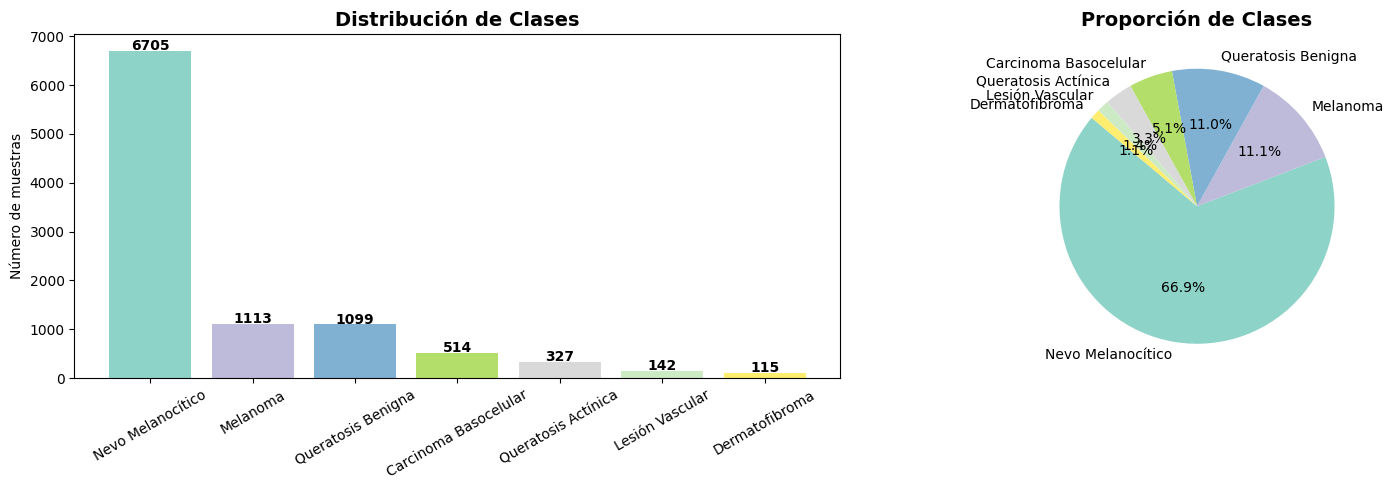

dx
nv       6705
mel      1113
bkl      1099
bcc       514
akiec     327
vasc      142
df        115
Name: count, dtype: int64


In [6]:
# Distribución de clases
class_counts = df['dx'].value_counts()
colors = plt.cm.Set3(np.linspace(0, 1, NUM_CLASSES))

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

bars = axes[0].bar([CLASS_LABELS[c] for c in class_counts.index],
                   class_counts.values, color=colors)
axes[0].set_title('Distribución de Clases', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Número de muestras')
axes[0].tick_params(axis='x', rotation=30)
for bar, val in zip(bars, class_counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 20,
                 str(val), ha='center', fontweight='bold')

axes[1].pie(class_counts.values,
            labels=[CLASS_LABELS[c] for c in class_counts.index],
            autopct='%1.1f%%', colors=colors, startangle=140)
axes[1].set_title('Proporción de Clases', fontsize=14, fontweight='bold')

plt.tight_layout()
#plt.savefig('class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print(class_counts)

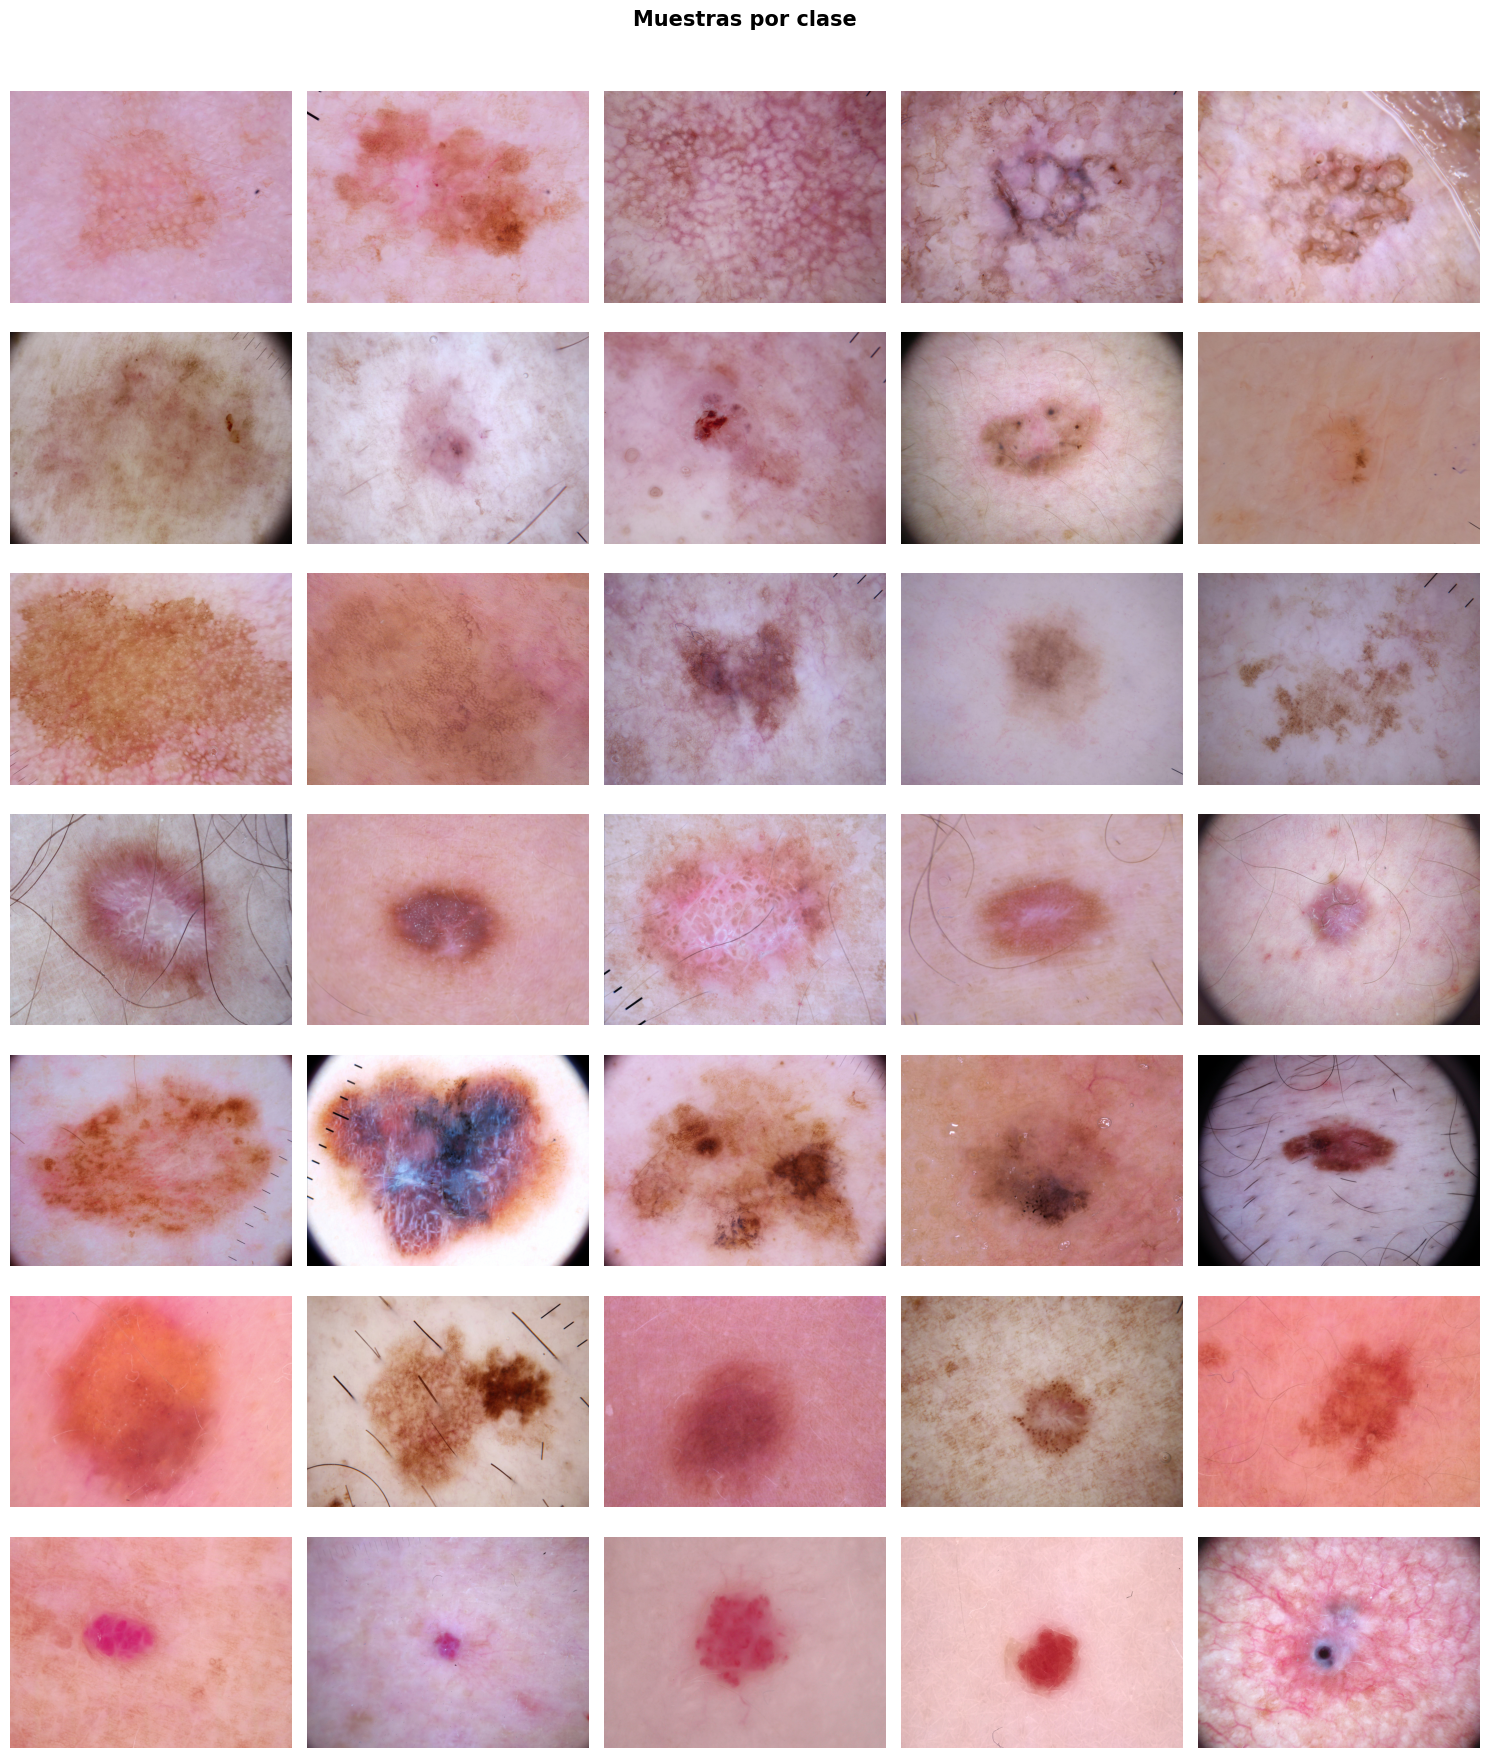

In [7]:
# Visualizar 5 ejemplos por clase
fig, axes = plt.subplots(NUM_CLASSES, 5, figsize=(15, NUM_CLASSES * 2.5))
fig.suptitle('Muestras por clase', fontsize=15, fontweight='bold', y=1.01)

for i, cls in enumerate(CLASS_NAMES):
    samples = df[df['dx'] == cls].sample(5, random_state=SEED)
    for j, (_, row) in enumerate(samples.iterrows()):
        axes[i, j].imshow(Image.open(row['path']))
        axes[i, j].axis('off')
        if j == 0:
            axes[i, j].set_ylabel(CLASS_LABELS[cls], fontsize=9, fontweight='bold')

plt.tight_layout()
plt.savefig('sample_images.png', dpi=100, bbox_inches='tight')
plt.show()

## 5. División del Dataset y Generadores de Datos

In [8]:
from sklearn.model_selection import GroupShuffleSplit

# 1. Creamos las columnas de etiquetas numéricas y en string que el modelo necesita
df['label']     = df['dx'].map({cls: i for i, cls in enumerate(CLASS_NAMES)})
df['label_str'] = df['dx']

# 2. Separar un 15% para TEST, agrupando por la lesión (evitando el data leakage)
gss_test = GroupShuffleSplit(n_splits=1, test_size=0.15, random_state=SEED)
trainval_idx, test_idx = next(gss_test.split(df, groups=df['lesion_id']))

df_trainval = df.iloc[trainval_idx].copy()
df_test = df.iloc[test_idx].copy()

# 3. Separar un 15% (del total original) para VALIDACIÓN, desde el grupo trainval
# El test_size relativo es aprox 0.1765
gss_val = GroupShuffleSplit(n_splits=1, test_size=0.1765, random_state=SEED)
train_idx, val_idx = next(gss_val.split(df_trainval, groups=df_trainval['lesion_id']))

df_train = df_trainval.iloc[train_idx].copy()
df_val = df_trainval.iloc[val_idx].copy()

# 4. Imprimimos el resultado para comprobar que todo cuadra
print(f"Train:      {len(df_train):>5}  ({len(df_train)/len(df)*100:.1f}%)")
print(f"Validación: {len(df_val):>5}  ({len(df_val)/len(df)*100:.1f}%)")
print(f"Test:       {len(df_test):>5}  ({len(df_test)/len(df)*100:.1f}%)")

Train:       6959  (69.5%)
Validación:  1529  (15.3%)
Test:        1527  (15.2%)


In [9]:
# Pesos de clase para manejar el desbalance
cw_array = compute_class_weight(
    class_weight='balanced',
    classes=np.arange(NUM_CLASSES),
    y=df_train['label'].values
)
class_weights = {i: w for i, w in enumerate(cw_array)}

print('Pesos por clase:')
for i, cls in enumerate(CLASS_NAMES):
    print(f'  [{i}] {CLASS_LABELS[cls]:<30} → {class_weights[i]:.4f}')

Pesos por clase:
  [0] Queratosis Actínica            → 4.4781
  [1] Carcinoma Basocelular          → 2.8485
  [2] Queratosis Benigna             → 1.2911
  [3] Dermatofibroma                 → 10.8059
  [4] Melanoma                       → 1.2894
  [5] Nevo Melanocítico              → 0.2132
  [6] Lesión Vascular                → 10.6897


In [10]:
preprocess_input = tf.keras.applications.resnet50.preprocess_input

# Generador de entrenamiento con data augmentation
train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=20,
    width_shift_range=0.1,
    height_shift_range=0.1,
    shear_range=0.1,
    zoom_range=0.15,
    horizontal_flip=True,
    vertical_flip=True,
    brightness_range=[0.8, 1.2],
    fill_mode='nearest'
)

# Sin augmentation para validación y test
val_test_datagen = ImageDataGenerator(preprocessing_function=preprocess_input)

def make_generator(datagen, df_split, shuffle=False):
    return datagen.flow_from_dataframe(
        dataframe=df_split,
        x_col='path',
        y_col='label_str',
        target_size=IMG_SIZE,
        batch_size=BATCH_SIZE,
        class_mode='categorical',
        classes=CLASS_NAMES,
        shuffle=shuffle,
        seed=SEED
    )

train_gen = make_generator(train_datagen, df_train, shuffle=True)
val_gen   = make_generator(val_test_datagen, df_val)
test_gen  = make_generator(val_test_datagen, df_test)

print(f'Steps/epoch train: {len(train_gen)}')
print(f'Steps/epoch val:   {len(val_gen)}')
print(f'Steps test:        {len(test_gen)}')

Found 6959 validated image filenames belonging to 7 classes.
Found 1529 validated image filenames belonging to 7 classes.
Found 1527 validated image filenames belonging to 7 classes.
Steps/epoch train: 218
Steps/epoch val:   48
Steps test:        48


## 6. Construcción del Modelo ResNet50

2026-06-04 16:17:50.356829: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:887] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
2026-06-04 16:17:50.357001: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:887] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
2026-06-04 16:17:50.357079: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:887] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
2026-06-04 16:17:50.357093: W tensorflow/core/common_runtime/gpu/gpu_device.cc:2348] TensorFlow was not built with CUDA kernel binaries compatible with compute capability 12.0. CUDA kernels will be jit-compiled from PTX, which could take 30 minutes or longer.
2026-06-04 16:17:50.620159: I external/lo

Capas base ResNet50:        175
Parámetros totales:         24,778,119
Parámetros entrenables:     1,186,311
Model: "HAM10000_ResNet50"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_image (InputLayer)    [(None, 224, 224, 3)]     0         
                                                                 
 resnet50 (Functional)       (None, 7, 7, 2048)        23587712  
                                                                 
 gap (GlobalAveragePooling2  (None, 2048)              0         
 D)                                                              
                                                                 
 bn_top (BatchNormalization  (None, 2048)              8192      
 )                                                               
                                                                 
 fc1 (Dense)                 (None, 512)               1049088   
      

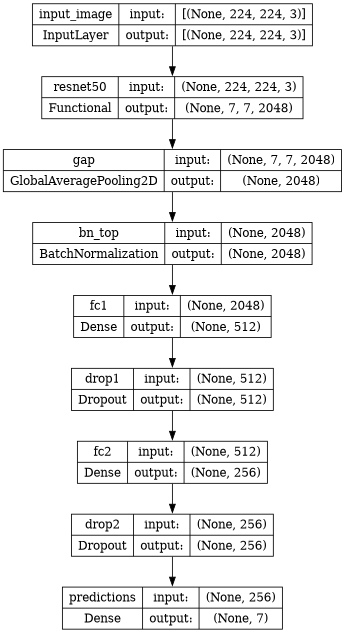

In [11]:
def build_model(num_classes, input_shape=(224, 224, 3), freeze_base=True):
    """
    ResNet50 preentrenada con ImageNet + cabeza de clasificación personalizada.
    
    Arquitectura:
      Input → ResNet50 (base) → GlobalAvgPool → BN → Dense(512,relu)
              → Dropout(0.5) → Dense(256,relu) → Dropout(0.3) → Dense(N,softmax)
    """
    base = ResNet50(weights='imagenet', include_top=False, input_shape=input_shape)
    base.trainable = not freeze_base

    inputs = keras.Input(shape=input_shape, name='input_image')
    x = base(inputs, training=False)   # BN de la base en modo inferencia
    x = layers.GlobalAveragePooling2D(name='gap')(x)
    x = layers.BatchNormalization(name='bn_top')(x)
    x = layers.Dense(512, activation='relu', name='fc1')(x)
    x = layers.Dropout(0.5, name='drop1')(x)
    x = layers.Dense(256, activation='relu', name='fc2')(x)
    x = layers.Dropout(0.3, name='drop2')(x)
    outputs = layers.Dense(num_classes, activation='softmax', name='predictions')(x)

    return Model(inputs, outputs, name='HAM10000_ResNet50'), base


model, base_model = build_model(NUM_CLASSES, input_shape=IMG_SIZE + (3,), freeze_base=True)

model.compile(
    optimizer=Adam(learning_rate=LR_FROZEN),
    loss='categorical_crossentropy',
    metrics=[
        'accuracy',
        tf.keras.metrics.AUC(name='auc'),
        tf.keras.metrics.Precision(name='precision'),
        tf.keras.metrics.Recall(name='recall')
    ]
)

print(f'Capas base ResNet50:        {len(base_model.layers)}')
print(f'Parámetros totales:         {model.count_params():,}')
print(f'Parámetros entrenables:     {sum(np.prod(v.shape) for v in model.trainable_variables):,}')
model.summary()
plot_model(model, show_shapes=True, dpi=60, show_layer_names=True, rankdir='TB', to_file='modelo_resnet50.png')

## 7. Fase 1 - Entrenamiento con Base Congelada

In [12]:
callbacks_p1 = [
    ModelCheckpoint('best_phase1.keras', monitor='val_auc', mode='max',
                    save_best_only=True, verbose=1),
    EarlyStopping(monitor='val_auc', mode='max', patience=7,
                  restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3,
                      min_lr=1e-7, verbose=1)
]

print('=' * 55)
print('FASE 1: Base ResNet50 CONGELADA')
print('=' * 55)

history1 = model.fit(
    train_gen,
    epochs=EPOCHS_FROZEN,
    validation_data=val_gen,
    class_weight=class_weights,
    callbacks=callbacks_p1,
    verbose=1
)

FASE 1: Base ResNet50 CONGELADA
Epoch 1/15


2026-06-04 16:17:56.055288: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:454] Loaded cuDNN version 8902
2026-06-04 16:17:56.089248: I external/local_tsl/tsl/platform/default/subprocess.cc:304] Start cannot spawn child process: No such file or directory
2026-06-04 16:17:56.131021: W external/local_xla/xla/stream_executor/gpu/asm_compiler.cc:225] Falling back to the CUDA driver for PTX compilation; ptxas does not support CC 12.0
2026-06-04 16:17:56.131093: W external/local_xla/xla/stream_executor/gpu/asm_compiler.cc:228] Used ptxas at /home/jesus/repos/TFM_resnet/.venv/lib/python3.11/site-packages/tensorflow/python/platform/../../../nvidia/cuda_nvcc/bin/ptxas
2026-06-04 16:17:56.131187: W tensorflow/compiler/mlir/tools/kernel_gen/transforms/gpu_kernel_to_blob_pass.cc:191] Failed to compile generated PTX with ptxas. Falling back to compilation by driver.
2026-06-04 16:17:56.238461: I external/local_tsl/tsl/platform/default/subprocess.cc:304] Start cannot spawn child process: 

  1/218 [..............................] - ETA: 22:06 - loss: 1.9887 - accuracy: 0.0938 - auc: 0.3959 - precision: 0.1333 - recall: 0.0625

2026-06-04 16:17:59.468856: W tensorflow/compiler/mlir/tools/kernel_gen/transforms/gpu_kernel_to_blob_pass.cc:191] Failed to compile generated PTX with ptxas. Falling back to compilation by driver.


218/218 [==============================] - ETA: 0s - loss: 2.0550 - accuracy: 0.4397 - auc: 0.7936 - precision: 0.4972 - recall: 0.3673
Epoch 1: val_auc improved from -inf to 0.92347, saving model to best_phase1.keras
218/218 [==============================] - 79s 336ms/step - loss: 2.0550 - accuracy: 0.4397 - auc: 0.7936 - precision: 0.4972 - recall: 0.3673 - val_loss: 0.9584 - val_accuracy: 0.6593 - val_auc: 0.9235 - val_precision: 0.8675 - val_recall: 0.4794 - lr: 0.0010
Epoch 2/15
218/218 [==============================] - ETA: 0s - loss: 1.5344 - accuracy: 0.4818 - auc: 0.8365 - precision: 0.5750 - recall: 0.3887
Epoch 2: val_auc did not improve from 0.92347
218/218 [==============================] - 75s 346ms/step - loss: 1.5344 - accuracy: 0.4818 - auc: 0.8365 - precision: 0.5750 - recall: 0.3887 - val_loss: 1.0090 - val_accuracy: 0.5958 - val_auc: 0.9153 - val_precision: 0.7761 - val_recall: 0.4284 - lr: 0.0010
Epoch 3/15
218/218 [==============================] - ETA: 0s - los

## 8. Fase 2 - Fine-Tuning

In [13]:
print('=' * 55)
print(f'FASE 2: Descongelando capas > {FINETUNE_FROM} de ResNet50')
print('=' * 55)

base_model.trainable = True

# Congelar las capas inferiores
for layer in base_model.layers[:FINETUNE_FROM]:
    layer.trainable = False

# BatchNorm siempre en modo inferencia para evitar inestabilidad
for layer in base_model.layers:
    if isinstance(layer, layers.BatchNormalization):
        layer.trainable = False

print(f'Parámetros entrenables: {sum(np.prod(v.shape) for v in model.trainable_variables):,}')

model.compile(
    optimizer=Adam(learning_rate=LR_FINETUNE),
    loss='categorical_crossentropy',
    metrics=[
        'accuracy',
        tf.keras.metrics.AUC(name='auc'),
        tf.keras.metrics.Precision(name='precision'),
        tf.keras.metrics.Recall(name='recall')
    ]
)

callbacks_p2 = [
    ModelCheckpoint('best_finetune.keras', monitor='val_auc', mode='max', save_best_only=True, verbose=1),
    EarlyStopping(monitor='val_auc', mode='max', patience=10, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.3, patience=4, min_lr=1e-8, verbose=1)
]

history2 = model.fit(
    train_gen,
    epochs=EPOCHS_FINETUNE,
    validation_data=val_gen,
    class_weight=class_weights,
    callbacks=callbacks_p2,
    verbose=1
)

FASE 2: Descongelando capas > 140 de ResNet50
Parámetros entrenables: 16,139,783
Epoch 1/25
218/218 [==============================] - ETA: 0s - loss: 0.8063 - accuracy: 0.6386 - auc: 0.9277 - precision: 0.7242 - recall: 0.5574
Epoch 1: val_auc improved from -inf to 0.92947, saving model to best_finetune.keras
218/218 [==============================] - 74s 305ms/step - loss: 0.8063 - accuracy: 0.6386 - auc: 0.9277 - precision: 0.7242 - recall: 0.5574 - val_loss: 0.9123 - val_accuracy: 0.6246 - val_auc: 0.9295 - val_precision: 0.7445 - val_recall: 0.5337 - lr: 1.0000e-05
Epoch 2/25
218/218 [==============================] - ETA: 0s - loss: 0.7340 - accuracy: 0.6558 - auc: 0.9338 - precision: 0.7425 - recall: 0.5689
Epoch 2: val_auc did not improve from 0.92947
218/218 [==============================] - 68s 310ms/step - loss: 0.7340 - accuracy: 0.6558 - auc: 0.9338 - precision: 0.7425 - recall: 0.5689 - val_loss: 0.9191 - val_accuracy: 0.6246 - val_auc: 0.9286 - val_precision: 0.7488 - v

## 9. Visualización del Entrenamiento

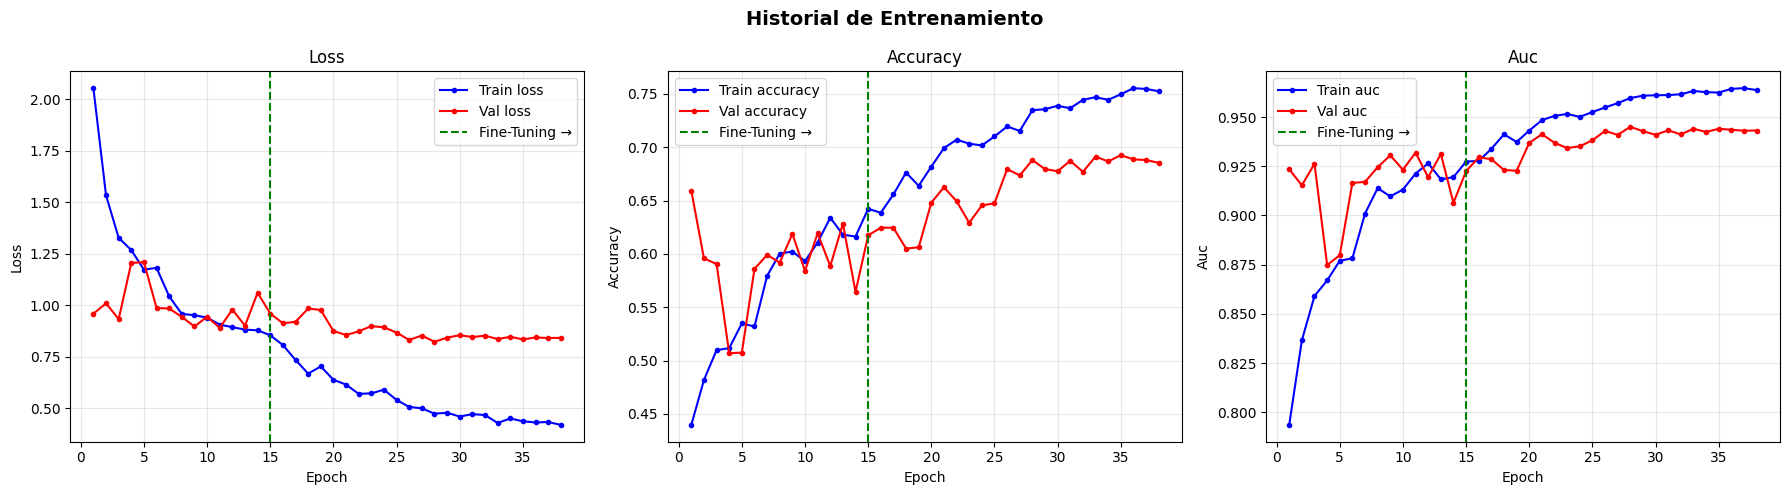

In [14]:
def plot_history(h1, h2, metrics=('loss', 'accuracy', 'auc')):
    combined = {k: h1.history[k] + h2.history[k] for k in h1.history}
    boundary = len(h1.history['loss'])
    x = range(1, len(combined['loss']) + 1)

    fig, axes = plt.subplots(1, len(metrics), figsize=(6 * len(metrics), 5))
    fig.suptitle('Historial de Entrenamiento', fontsize=14, fontweight='bold')

    for ax, m in zip(axes, metrics):
        ax.plot(x, combined[m],           'b-o', ms=3, label=f'Train {m}')
        ax.plot(x, combined[f'val_{m}'],  'r-o', ms=3, label=f'Val {m}')
        ax.axvline(boundary, color='green', ls='--', lw=1.5, label='Fine-Tuning →')
        ax.set_xlabel('Epoch'); ax.set_ylabel(m.capitalize())
        ax.set_title(m.capitalize()); ax.legend(); ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig('training_history.png', dpi=150, bbox_inches='tight')
    plt.show()

plot_history(history1, history2)

## 10. Evaluación en el Conjunto de Test

In [15]:
best_model = keras.models.load_model('best_finetune.keras')

print('Evaluando en test...')
test_results = best_model.evaluate(test_gen, verbose=1)

print('\n' + '='*50)
print('MÉTRICAS EN TEST')
print('='*50)
for name, val in zip(best_model.metrics_names, test_results):
    print(f'  {name:<15}: {val:.4f}')

Evaluando en test...
48/48 [==============================] - 10s 172ms/step - loss: 0.8380 - accuracy: 0.6771 - auc: 0.9432 - precision: 0.7292 - recall: 0.6156

MÉTRICAS EN TEST
  loss           : 0.8380
  accuracy       : 0.6771
  auc            : 0.9432
  precision      : 0.7292
  recall         : 0.6156


In [16]:
# Predicciones
test_gen.reset()
y_proba = best_model.predict(test_gen, verbose=1)
y_pred  = np.argmax(y_proba, axis=1)
y_true  = test_gen.classes

print('\nREPORTE DE CLASIFICACIÓN')
print('='*70)
print(classification_report(
    y_true, y_pred,
    target_names=[CLASS_LABELS[c] for c in CLASS_NAMES]
))

48/48 [==============================] - 7s 123ms/step

REPORTE DE CLASIFICACIÓN
                       precision    recall  f1-score   support

  Queratosis Actínica       0.48      0.31      0.38        48
Carcinoma Basocelular       0.58      0.64      0.60        66
   Queratosis Benigna       0.47      0.72      0.57       172
       Dermatofibroma       0.17      0.70      0.28        10
             Melanoma       0.36      0.73      0.49       186
    Nevo Melanocítico       0.97      0.68      0.80      1016
      Lesión Vascular       0.62      0.69      0.66        29

             accuracy                           0.68      1527
            macro avg       0.52      0.64      0.54      1527
         weighted avg       0.79      0.68      0.71      1527



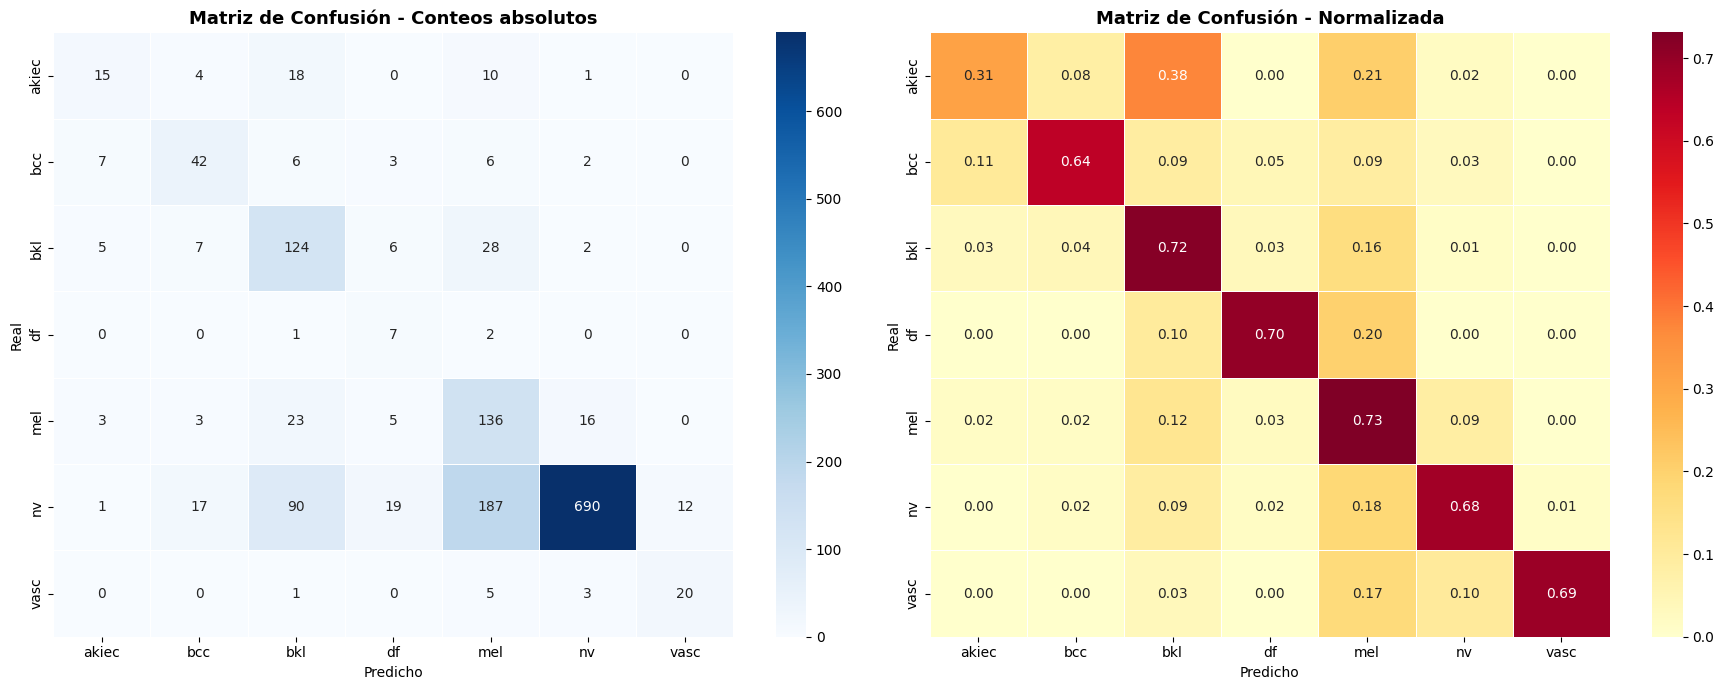

In [17]:
# Matrices de confusión
cm = confusion_matrix(y_true, y_pred)
cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

fig, axes = plt.subplots(1, 2, figsize=(18, 7))
for ax, data, fmt, title in zip(
        axes,
        [cm, cm_norm],
        ['d', '.2f'],
        ['Conteos absolutos', 'Normalizada']):
    sns.heatmap(data, annot=True, fmt=fmt, cmap='Blues' if fmt=='d' else 'YlOrRd',
                xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
                ax=ax, linewidths=0.5)
    ax.set_title(f'Matriz de Confusión - {title}', fontsize=13, fontweight='bold')
    ax.set_ylabel('Real'); ax.set_xlabel('Predicho')

plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

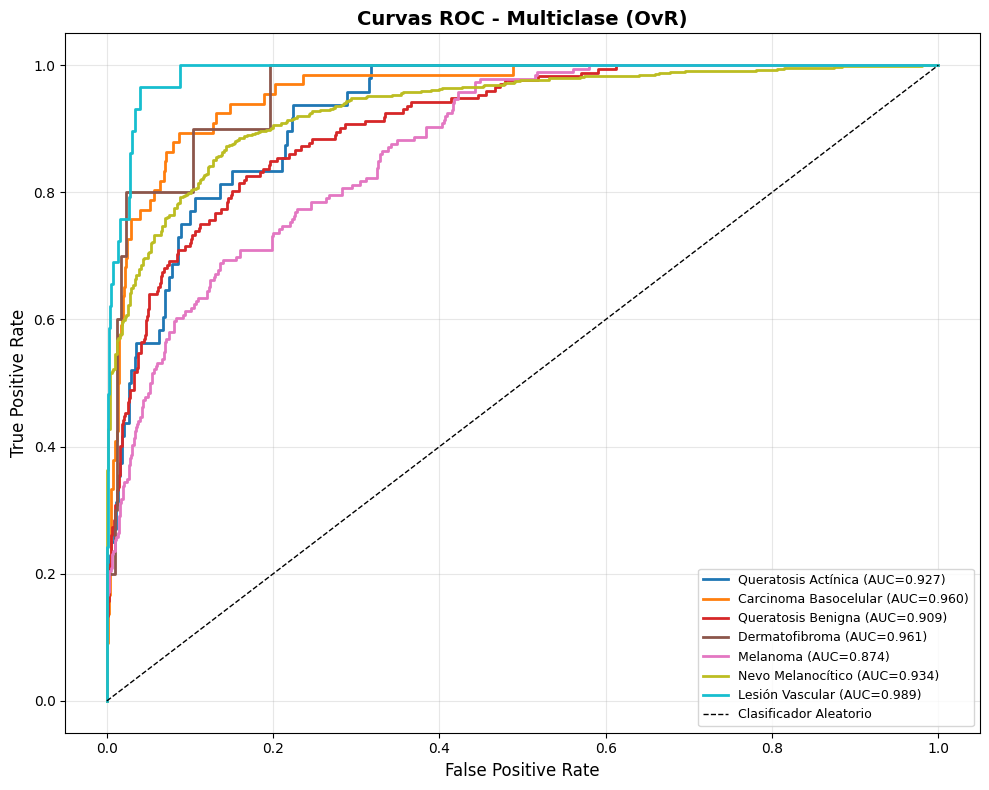


AUC por clase:
  Queratosis Actínica                 AUC = 0.9270
  Carcinoma Basocelular               AUC = 0.9601
  Queratosis Benigna                  AUC = 0.9091
  Dermatofibroma                      AUC = 0.9614
  Melanoma                            AUC = 0.8736
  Nevo Melanocítico                   AUC = 0.9345
  Lesión Vascular                     AUC = 0.9885

  Macro-AUC: 0.9363


In [18]:
# Curvas ROC One-vs-Rest
y_bin = label_binarize(y_true, classes=range(NUM_CLASSES))
colors_roc = plt.cm.tab10(np.linspace(0, 1, NUM_CLASSES))

fig, ax = plt.subplots(figsize=(10, 8))
auc_scores = {}
for i, (cls, col) in enumerate(zip(CLASS_NAMES, colors_roc)):
    fpr, tpr, _ = roc_curve(y_bin[:, i], y_proba[:, i])
    roc_auc = auc(fpr, tpr)
    auc_scores[cls] = roc_auc
    ax.plot(fpr, tpr, color=col, lw=2,
            label=f'{CLASS_LABELS[cls]} (AUC={roc_auc:.3f})')

ax.plot([0,1],[0,1],'k--',lw=1, label='Clasificador Aleatorio')
ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate', fontsize=12)
ax.set_title('Curvas ROC - Multiclase (OvR)', fontsize=14, fontweight='bold')
ax.legend(loc='lower right', fontsize=9)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('roc_curves.png', dpi=150, bbox_inches='tight')
plt.show()

print('\nAUC por clase:')
for cls, s in auc_scores.items():
    print(f'  {CLASS_LABELS[cls]:<35} AUC = {s:.4f}')
print(f'\n  Macro-AUC: {np.mean(list(auc_scores.values())):.4f}')

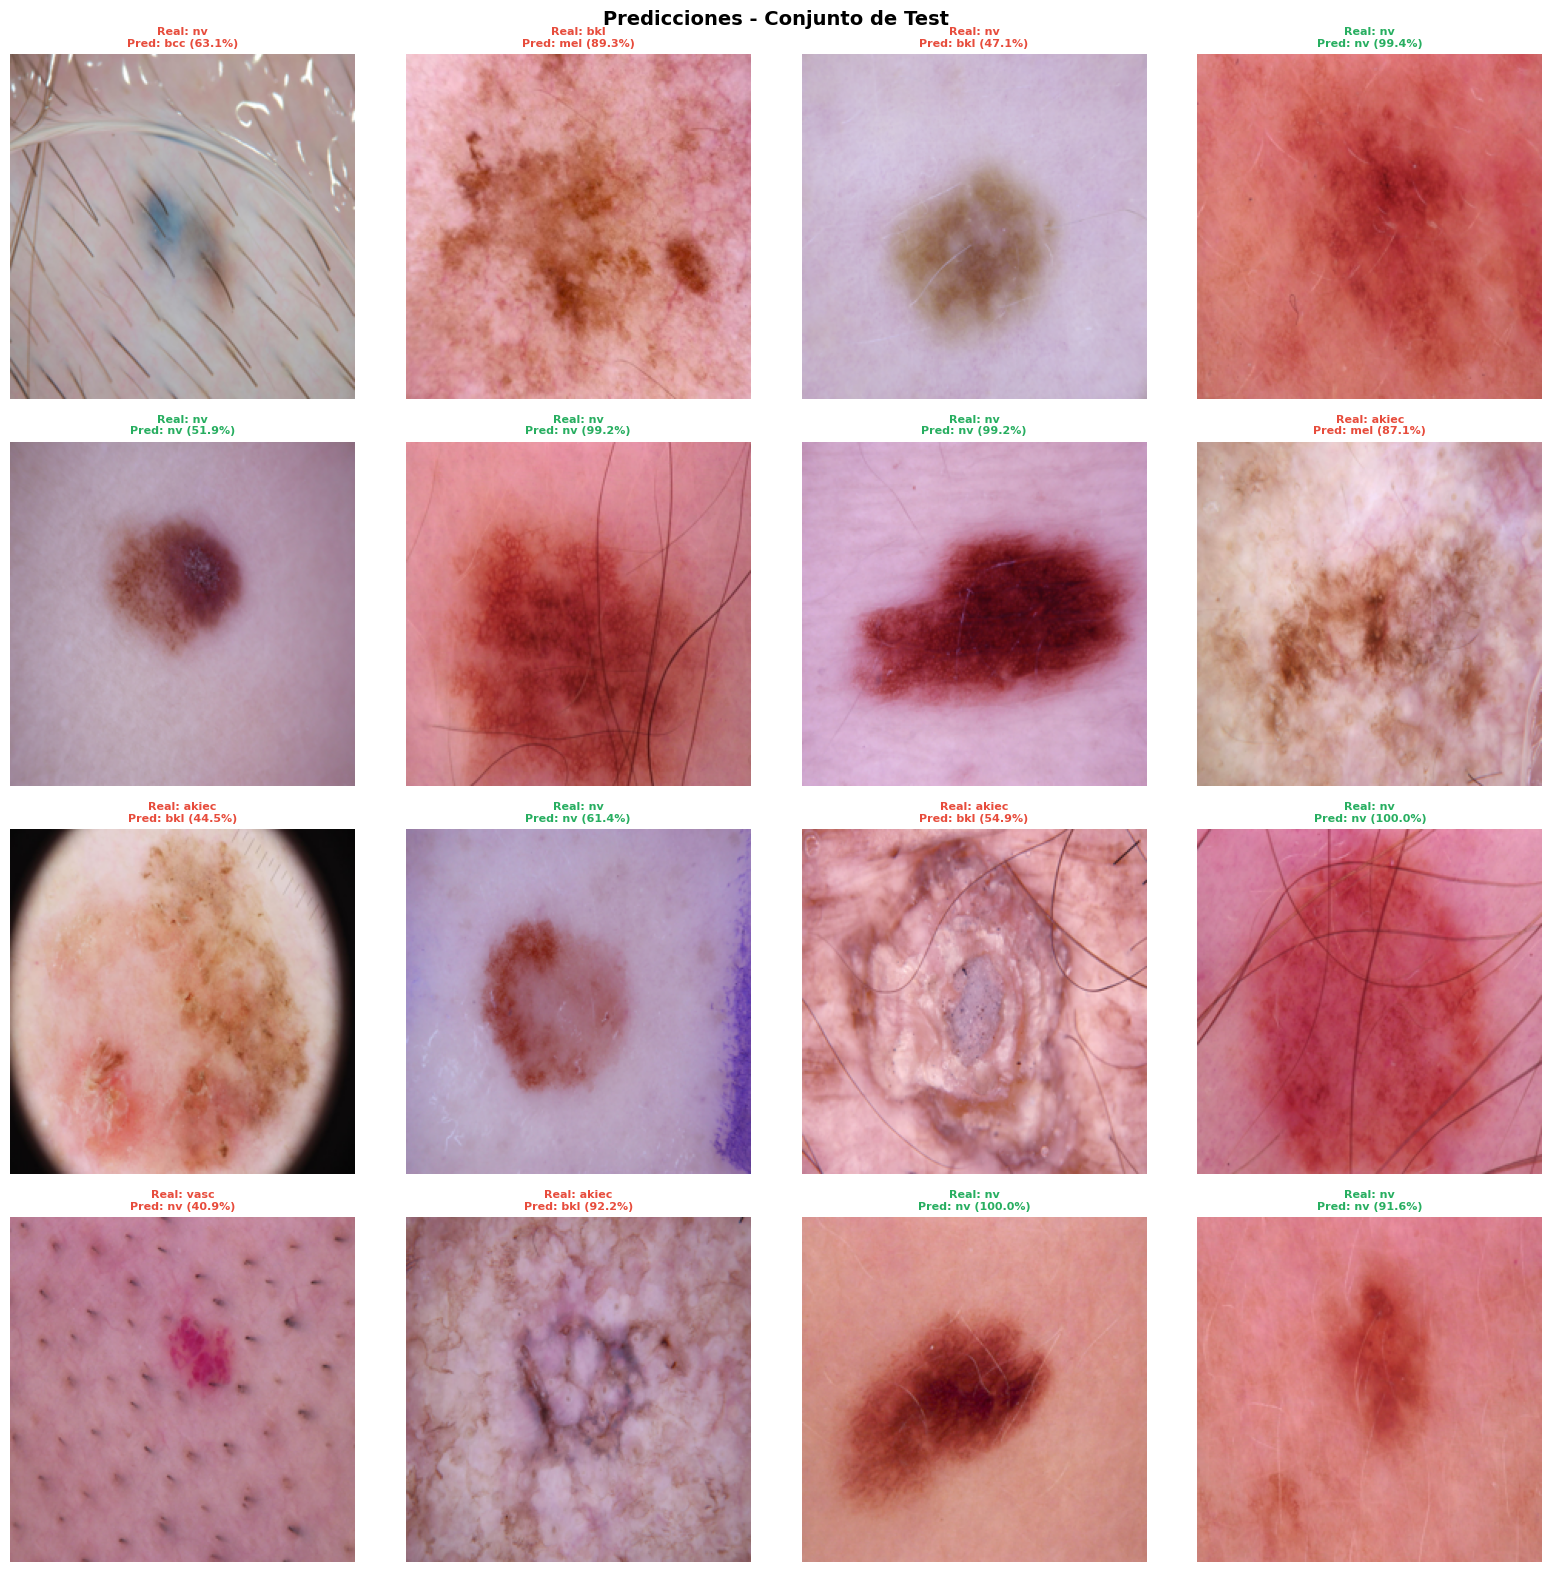

In [19]:
# Visualización de predicciones individuales
test_df_reset = df_test.reset_index(drop=True)
idx = np.random.RandomState(SEED).choice(len(test_df_reset), 16, replace=False)

fig, axes = plt.subplots(4, 4, figsize=(16, 16))
fig.suptitle('Predicciones - Conjunto de Test', fontsize=14, fontweight='bold')

for ax, i in zip(axes.flatten(), idx):
    img = Image.open(test_df_reset.loc[i, 'path']).resize(IMG_SIZE)
    true_cls = CLASS_NAMES[y_true[i]]
    pred_cls = CLASS_NAMES[y_pred[i]]
    conf     = y_proba[i, y_pred[i]]
    correct  = y_true[i] == y_pred[i]
    color    = '#27AE60' if correct else '#E74C3C'
    ax.imshow(img)
    ax.axis('off')
    ax.set_title(f'Real: {true_cls}\nPred: {pred_cls} ({conf:.1%})',
                 fontsize=8, color=color, fontweight='bold')

plt.tight_layout()
plt.savefig('predictions_sample.png', dpi=120, bbox_inches='tight')
plt.show()

## 11. Guardar el Modelo Final

In [20]:
best_model.save('HAM10000_ResNet50_final.keras')
best_model.save_weights('HAM10000_ResNet50.weights.h5')
print('Modelo guardado: HAM10000_ResNet50_final.keras')
print('Pesos guardados: HAM10000_ResNet50.weights.h5')

print('\n' + '='*55)
print('RESUMEN FINAL')
print('='*55)
print(f'  Epochs Fase 1:   {len(history1.history["loss"])}')
print(f'  Epochs Fase 2:   {len(history2.history["loss"])}')
print(f'  Mejor val_auc P1: {max(history1.history["val_auc"]):.4f}')
print(f'  Mejor val_auc P2: {max(history2.history["val_auc"]):.4f}')
for name, val in zip(best_model.metrics_names, test_results):
    print(f'  Test {name:<12}: {val:.4f}')
print(f'  Macro-AUC OvR:   {np.mean(list(auc_scores.values())):.4f}')

Modelo guardado: HAM10000_ResNet50_final.keras
Pesos guardados: HAM10000_ResNet50.weights.h5

RESUMEN FINAL
  Epochs Fase 1:   15
  Epochs Fase 2:   23
  Mejor val_auc P1: 0.9319
  Mejor val_auc P2: 0.9450
  Test loss        : 0.8380
  Test accuracy    : 0.6771
  Test auc         : 0.9432
  Test precision   : 0.7292
  Test recall      : 0.6156
  Macro-AUC OvR:   0.9363


## 12. Función de Inferencia para Nuevas Imágenes

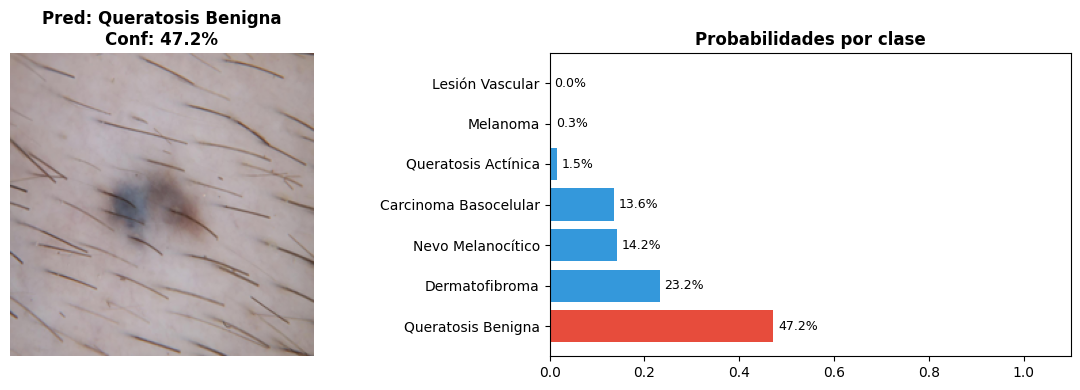


Clase predicha:  bkl - Queratosis Benigna
Confianza:       47.2%


In [21]:
def predict_image(image_path, model=best_model):
    """Predice la clase de una imagen de lesión cutánea y muestra la distribución."""
    prep = tf.keras.applications.resnet50.preprocess_input
    img = Image.open(image_path).convert('RGB').resize(IMG_SIZE)
    arr = prep(np.array(img, dtype=np.float32))
    arr = np.expand_dims(arr, 0)

    proba    = model.predict(arr, verbose=0)[0]
    pred_idx = int(np.argmax(proba))
    pred_cls = CLASS_NAMES[pred_idx]

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
    ax1.imshow(img); ax1.axis('off')
    ax1.set_title(f'Pred: {CLASS_LABELS[pred_cls]}\nConf: {proba[pred_idx]:.1%}',
                  fontweight='bold', fontsize=12)

    sorted_pairs = sorted(zip(CLASS_NAMES, proba), key=lambda x: x[1], reverse=True)
    lbls  = [CLASS_LABELS[c] for c, _ in sorted_pairs]
    vals  = [v for _, v in sorted_pairs]
    cols  = ['#E74C3C' if c == pred_cls else '#3498DB' for c, _ in sorted_pairs]
    bars  = ax2.barh(lbls, vals, color=cols)
    for bar, v in zip(bars, vals):
        ax2.text(v + 0.01, bar.get_y() + bar.get_height()/2,
                 f'{v:.1%}', va='center', fontsize=9)
    ax2.set_xlim(0, 1.1)
    ax2.set_title('Probabilidades por clase', fontweight='bold')
    plt.tight_layout(); plt.show()

    return {'class': pred_cls, 'label': CLASS_LABELS[pred_cls],
            'confidence': float(proba[pred_idx]),
            'probabilities': dict(zip(CLASS_NAMES, proba.tolist()))}


# Ejemplo con una imagen aleatoria del test
sample_path = df_test.sample(1, random_state=0)['path'].values[0]
result = predict_image(sample_path)
print(f"\nClase predicha:  {result['class']} - {result['label']}")
print(f"Confianza:       {result['confidence']:.1%}")